# ETL Pipeline and Database Benchmarks

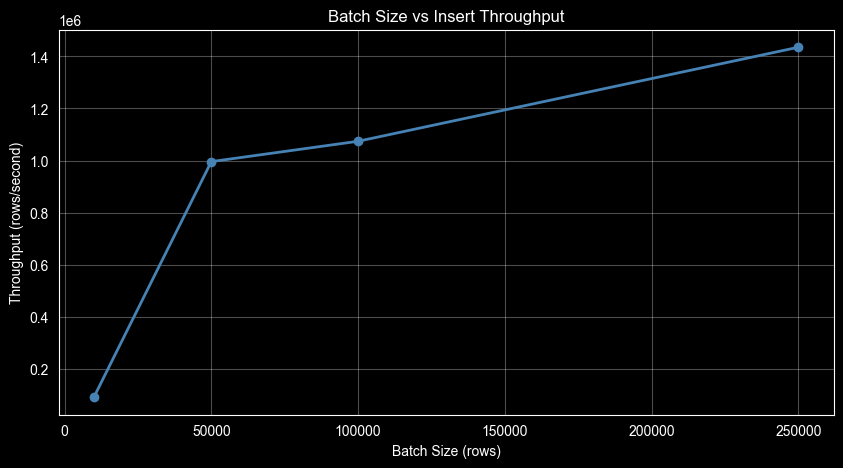

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Q1_funnel: 3.0871s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Q2_session: 101.12s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Q3_brand: 2.4092s
Q5_hourly: 0.3587s


In [1]:
import duckdb, time, os, sys
sys.path.append('..')
import matplotlib.pyplot as plt

# Connect to database
con = duckdb.connect('../ecommerce.duckdb')

# PERFORMANCE SETTINGS (Robust initialization)
try:
    con.execute("PRAGMA memory_limit='8GB'")
    con.execute("PRAGMA temp_directory='../duckdb_temp'")
    con.execute("PRAGMA max_temp_directory_size='100GiB'")
    con.execute("SET preserve_insertion_order=false")
except Exception as e:
    print(f"Note: Pragmas already set or could not be changed: {e}")

# --- 1. Batch Size vs Throughput ---
batch_results = [
    {'batch': 10000, 'rps': 92725},
    {'batch': 50000, 'rps': 996256},
    {'batch': 100000, 'rps': 1074273},
    {'batch': 250000, 'rps': 1434894}
]

plt.figure(figsize=(10,5))
plt.plot([r['batch'] for r in batch_results], [r['rps'] for r in batch_results],
         marker='o', linewidth=2, color='steelblue')
plt.xlabel('Batch Size (rows)')
plt.ylabel('Throughput (rows/second)')
plt.title('Batch Size vs Insert Throughput')
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. Query Performance ---
queries = {
    'Q1_funnel':   'SELECT p.category_main, COUNT(*) FROM fact_events e JOIN dim_product p ON e.product_key=p.product_key GROUP BY 1 LIMIT 20',
    'Q2_session':  'SELECT user_session, COUNT(*) FROM fact_events GROUP BY user_session LIMIT 10',
    'Q3_brand':    'SELECT p.brand, SUM(e.price) FROM fact_events e JOIN dim_product p ON e.product_key=p.product_key WHERE e.event_type=\'purchase\' GROUP BY 1 LIMIT 10',
    'Q5_hourly':   'SELECT d.hour, COUNT(*) FROM fact_events e JOIN dim_date d ON e.date_key=d.date_key WHERE e.event_type=\'purchase\' GROUP BY 1 ORDER BY 1'
}

for name, sql in queries.items():
    start = time.perf_counter()
    con.execute(sql).fetchall()
    elapsed = round(time.perf_counter() - start, 4)
    print(f"{name}: {elapsed}s")
